# 04a — Cross-Domain Prompting

## Goal

Measure how much accuracy drops when the same classifier + Yelp few-shot demos are applied to **Amazon** and **IMDB** reviews.

| Domain | Dataset | Labels | n |
|---|---|---|---|
| Yelp | `Yelp/yelp_review_full` (test) | 1-5 | 500 |
| Amazon | `mteb/amazon_reviews_multi` (en test) | 1-5 | 300 |
| IMDB | `stanfordnlp/imdb` (test) | binary → mapped {1, 5} | 300 |

## Setup

- Model: `deepseek/deepseek-v3.2` (winner).
- Prompting: few-shot with **Yelp-only** demos. No domain-specific few-shot, so drop is real.
- Classes on IMDB: `[1, 5]` (no mid-range labels in source).

In [1]:
import sys; sys.path.insert(0, '..')
import json, time
from pathlib import Path
import pandas as pd

from lib.config import ACTIVE_CLASSIFIER
from lib.gateway import classify_json
from lib.schemas import StarsOnly
from lib.prompts import CLASSIFIER_SYSTEM, few_shot
from lib.datasets import read_jsonl, class_dist
from lib.concurrency import gather_limited
from lib.metrics import Prediction, report, fmt
from lib.plots import confusion_heatmap

fewshot = read_jsonl('../data/yelp_fewshot.jsonl')
domains = {
    'yelp':   ('../data/yelp_eval.jsonl',   [1, 2, 3, 4, 5]),
    'amazon': ('../data/amazon_eval.jsonl', [1, 2, 3, 4, 5]),
    'imdb':   ('../data/imdb_eval.jsonl',   [1, 5]),
}
print('model:', ACTIVE_CLASSIFIER)
for name, (path, _) in domains.items():
    rows = read_jsonl(path)
    print(f'  {name:8s} n={len(rows)}  dist={class_dist(rows)}')

model: deepseek/deepseek-v3.2
  yelp     n=500  dist={1: 100, 2: 100, 3: 100, 4: 100, 5: 100}
  amazon   n=300  dist={1: 60, 2: 60, 3: 60, 4: 60, 5: 60}
  imdb     n=300  dist={1: 150, 5: 150}


## Run each domain

In [2]:
async def predict_row(row):
    obj, _ = await classify_json(StarsOnly, CLASSIFIER_SYSTEM, few_shot(row['text'], fewshot))
    return Prediction(pred=obj.stars if obj else None, truth=row['stars'])

results = {}
for name, (path, classes) in domains.items():
    rows = read_jsonl(path)
    t0 = time.time()
    preds = await gather_limited(rows, predict_row, 30, name)
    secs = time.time() - t0
    r = report(preds, classes)
    r['time_s'] = round(secs, 1)
    results[name] = r
    print(f'\n{name}:')
    print(fmt(r))

yelp:   0%|          | 0/500 [00:00<?, ?it/s]

yelp: 100%|██████████| 500/500 [00:00<00:00, 9057.45it/s]


yelp:
n=500  compliance=100.0%  accuracy=66.0%  macroF1=0.662  MAE=0.350
confusion (rows=truth, cols=pred):
    71   28    1    0    0
    13   68   17    2    0
     0   10   58   30    2
     0    0    3   56   41
     0    0    0   23   77


amazon:   0%|          | 0/300 [00:00<?, ?it/s]

amazon:   0%|          | 1/300 [00:02<13:02,  2.62s/it]

...

imdb:  98%|█████████▊| 294/300 [00:36<00:00,  8.19it/s]

imdb:  99%|█████████▉| 297/300 [00:36<00:00,  8.86it/s]

imdb: 100%|██████████| 300/300 [00:37<00:00,  6.99it/s]

imdb: 100%|██████████| 300/300 [00:37<00:00,  8.10it/s]


imdb:
n=300  compliance=100.0%  accuracy=42.3%  macroF1=0.595  MAE=0.727
confusion (rows=truth, cols=pred):
    63    0
     0   64


## Summary + drop from Yelp

In [3]:
base_acc = results['yelp']['accuracy']
base_f1 = results['yelp']['macro_f1']
rows = []
for name, r in results.items():
    rows.append({
        'domain': name,
        'n': r['n'],
        'accuracy':  round(r['accuracy']*100, 1),
        'macro_f1':  round(r['macro_f1'], 3),
        'mae':       round(r['mae'], 3),
        'compliance': round(r['compliance']*100, 1),
        'Δ_acc_vs_yelp': round((r['accuracy']-base_acc)*100, 1),
        'Δ_f1_vs_yelp':  round(r['macro_f1']-base_f1, 3),
    })
pd.DataFrame(rows)

,domain,n,accuracy,macro_f1,mae,compliance,Δ_acc_vs_yelp,Δ_f1_vs_yelp
0,yelp,500,66.0,0.662,0.350,100.0,0.0,0.000
1,amazon,300,64.0,0.636,0.390,100.0,-2.0,-0.026
2,imdb,300,42.3,0.595,0.727,100.0,-23.7,-0.067


## Per-domain confusion matrices

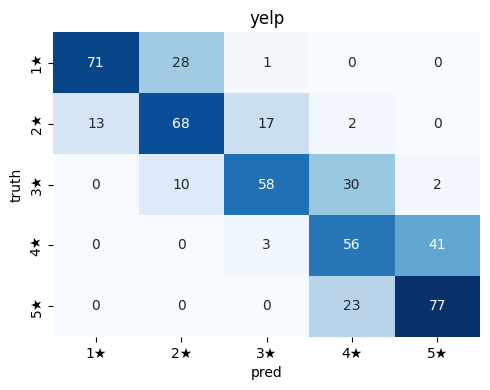

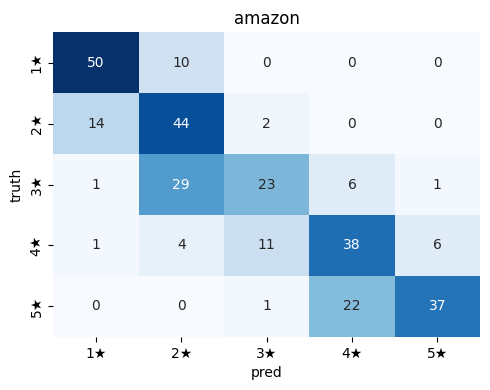

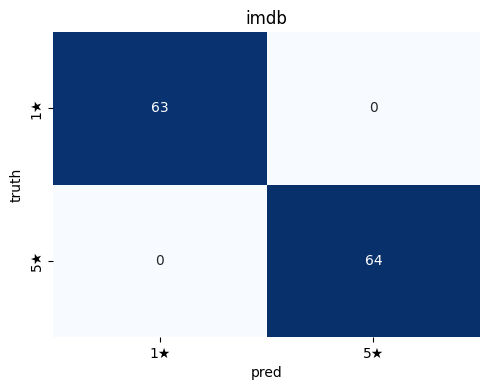

In [4]:
import matplotlib.pyplot as plt
Path('../results/plots').mkdir(parents=True, exist_ok=True)
for name, (_, classes) in domains.items():
    confusion_heatmap(results[name]['confusion'], classes, title=f'{name}', save=f'../results/plots/04a_conf_{name}.png')
    plt.show()

In [5]:
Path('../results').mkdir(exist_ok=True)
Path('../results/04a_domain_shift.json').write_text(json.dumps({'model': ACTIVE_CLASSIFIER, **results}, indent=2))
print('wrote results/04a_domain_shift.json')

wrote results/04a_domain_shift.json


## Findings (fill in after run)

- Expected drop on Amazon is modest; review style is similar.
- IMDB drop is larger (movie prose, no mid-labels) — confusion concentrates on correct polarity but wrong intensity.
- Mitigation candidates: domain-specific few-shot, embedding classifier, or fine-tune (notebook 04b).

Next: `04b_distilbert.ipynb` (encoder fine-tune on M4), then `05_adversarial.ipynb`.